# Practical 7: Keras MLP for Multiclass Classification (Wine Dataset)


## 1. Dataset Preparation


In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
# Load and explore the dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape of features:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("Class names:", data.target_names)
X.head()


Shape of features: (178, 13)
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Basic statistics / exploration
X.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [4]:
# Check for missing values
print("Missing values per column:\n", X.isnull().sum())
print("\nTotal missing values:", X.isnull().sum().sum())


Missing values per column:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Total missing values: 0


Class distribution:
 target
0    59
1    71
2    48
Name: count, dtype: int64


/tmp/ipykernel_1381/2901391951.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[data.target_names[i] for i in class_counts.index],


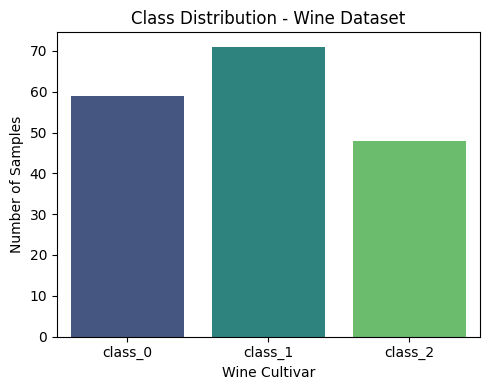

In [5]:
# Class distribution analysis
class_counts = y.value_counts().sort_index()
print("Class distribution:\n", class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=[data.target_names[i] for i in class_counts.index],
            y=class_counts.values, palette="viridis")
plt.title("Class Distribution - Wine Dataset")
plt.xlabel("Wine Cultivar")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


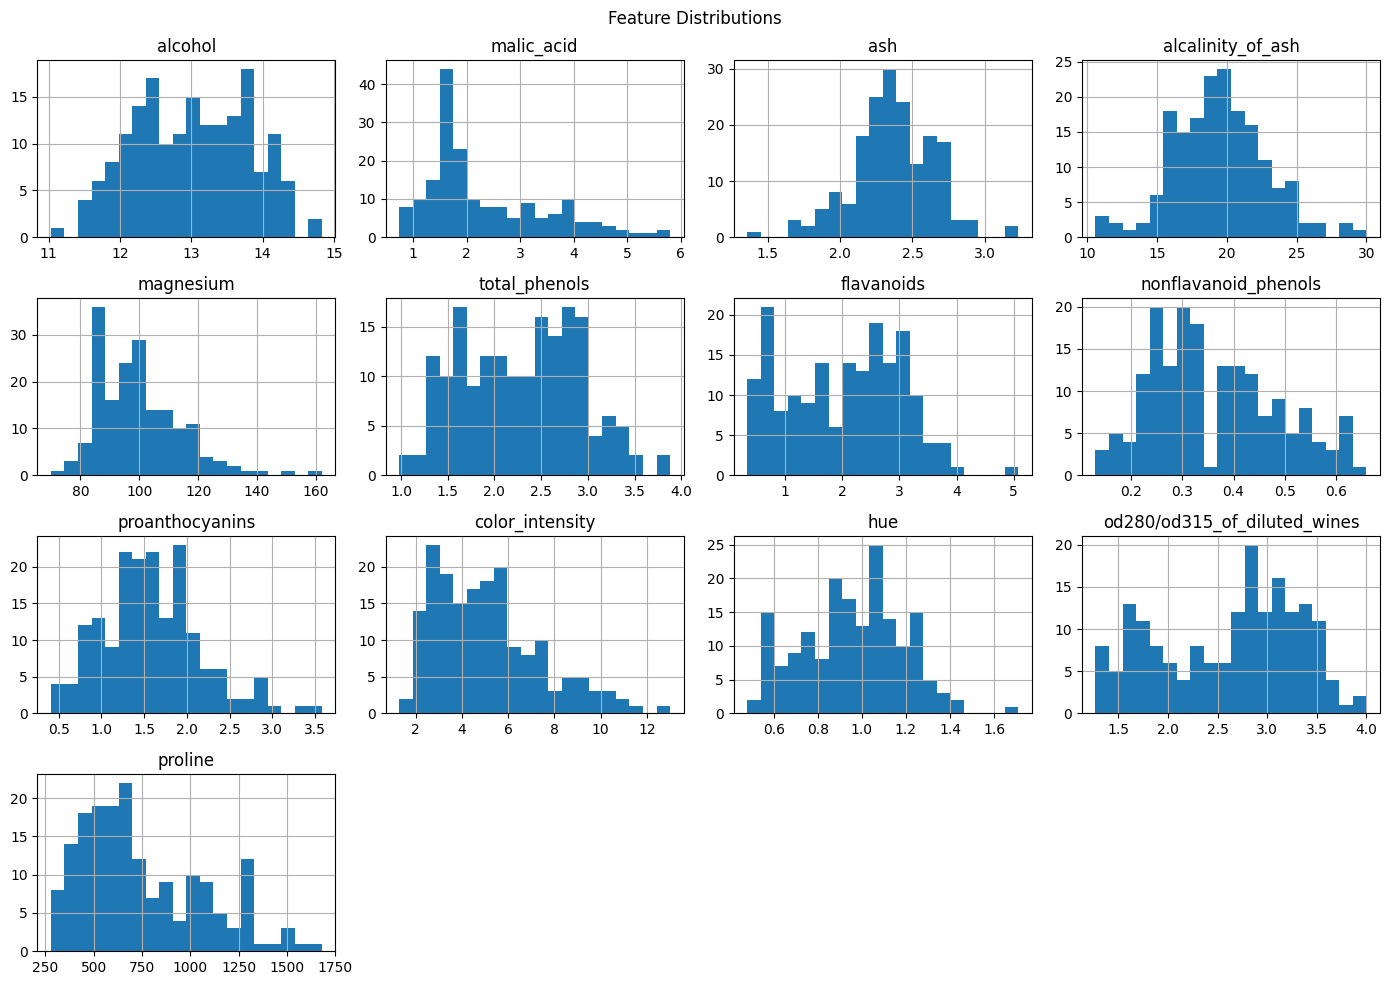

In [6]:
# Feature distributions (to check scale differences / non-linearity considerations)
X.hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()


In [7]:
# Encode target variable: integer labels -> one-hot vectors for softmax output
num_classes = len(np.unique(y))
y_onehot = to_categorical(y, num_classes=num_classes)
print("One-hot encoded target shape:", y_onehot.shape)
print("Example:", y_onehot[0], "-> class", y[0])


One-hot encoded target shape: (178, 3)
Example: [1. 0. 0.] -> class 0


In [8]:
# Train / test split (stratified to preserve class proportions)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X.values, y_onehot, test_size=0.2, random_state=SEED, stratify=y
)

print("Train shape:", X_train_raw.shape, " Test shape:", X_test_raw.shape)


Train shape: (142, 13)  Test shape: (36, 13)


In [9]:
# Feature scaling: fit scaler ONLY on training data, then transform train & test
# (prevents data leakage from the test set into preprocessing)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Post-scaling mean (train, approx 0):", X_train.mean(axis=0).round(2)[:5])
print("Post-scaling std (train, approx 1):", X_train.std(axis=0).round(2)[:5])


Post-scaling mean (train, approx 0): [ 0. -0.  0.  0.  0.]
Post-scaling std (train, approx 1): [1. 1. 1. 1. 1.]


## 2. MLP Model Development


In [10]:
def build_mlp(input_dim, num_classes, hidden_activation="relu", optimizer="adam"):
    """Builds and compiles an MLP with 2 hidden layers."""
    model = Sequential([
        Dense(32, activation=hidden_activation, input_shape=(input_dim,), name="hidden_1"),
        Dense(16, activation=hidden_activation, name="hidden_2"),
        Dense(num_classes, activation="softmax", name="output"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Quick summary for reporting: architecture with default settings (ReLU + Adam)
demo_model = build_mlp(X_train.shape[1], num_classes, "relu", "adam")
demo_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

## 3-5. Experiments (Activation Functions & Optimizers), Training, and Curves


In [11]:
EPOCHS = 100
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2

results = {}       # stores final metrics for the comparison table
histories = {}      # stores training history for plotting
models_dict = {}    # stores trained models (for confusion matrices)

def run_experiment(name, hidden_activation, optimizer):
    print(f"\n=== Running: {name} (activation={hidden_activation}, optimizer={optimizer}) ===")
    tf.random.set_seed(SEED)
    model = build_mlp(X_train.shape[1], num_classes, hidden_activation, optimizer)

    history = model.fit(
        X_train, y_train,
        validation_split=VALIDATION_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    # Evaluate on the held-out test set
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    test_acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    results[name] = {
        "activation": hidden_activation,
        "optimizer": optimizer,
        "train_acc": history.history["accuracy"][-1],
        "val_acc": history.history["val_accuracy"][-1],
        "train_loss": history.history["loss"][-1],
        "val_loss": history.history["val_loss"][-1],
        "test_accuracy": test_acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }
    histories[name] = history
    models_dict[name] = model

    print(f"Test accuracy: {test_acc:.4f} | Precision: {precision:.4f} "
          f"| Recall: {recall:.4f} | F1: {f1:.4f}")
    return model, history


### Experiment A - Hidden-Layer Activation Functions (optimizer fixed to Adam)


In [12]:
run_experiment("Model 1 (ReLU, Adam)",    "relu",    "adam")
run_experiment("Model 2 (Sigmoid, Adam)", "sigmoid", "adam")
run_experiment("Model 3 (Tanh, Adam)",    "tanh",    "adam")



=== Running: Model 1 (ReLU, Adam) (activation=relu, optimizer=adam) ===
Test accuracy: 0.9722 | Precision: 0.9778 | Recall: 0.9667 | F1: 0.9710

=== Running: Model 2 (Sigmoid, Adam) (activation=sigmoid, optimizer=adam) ===


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 0.9722 | Precision: 0.9778 | Recall: 0.9667 | F1: 0.9710

=== Running: Model 3 (Tanh, Adam) (activation=tanh, optimizer=adam) ===


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 0.9722 | Precision: 0.9778 | Recall: 0.9667 | F1: 0.9710


(<Sequential name=sequential_3, built=True>,
 <keras.src.callbacks.history.History at 0x7a5ddb37de50>)

### Experiment B - Optimizer Comparison (activation fixed to ReLU)


In [13]:
run_experiment("Model 4 (ReLU, SGD)",      "relu", "sgd")
run_experiment("Model 5 (ReLU, RMSprop)",  "relu", "rmsprop")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== Running: Model 4 (ReLU, SGD) (activation=relu, optimizer=sgd) ===
Test accuracy: 0.9167 | Precision: 0.9299 | Recall: 0.9095 | F1: 0.9151

=== Running: Model 5 (ReLU, RMSprop) (activation=relu, optimizer=rmsprop) ===


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 0.9722 | Precision: 0.9744 | Recall: 0.9762 | F1: 0.9743


(<Sequential name=sequential_5, built=True>,
 <keras.src.callbacks.history.History at 0x7a5ddb330d60>)

### Training / Validation Curves


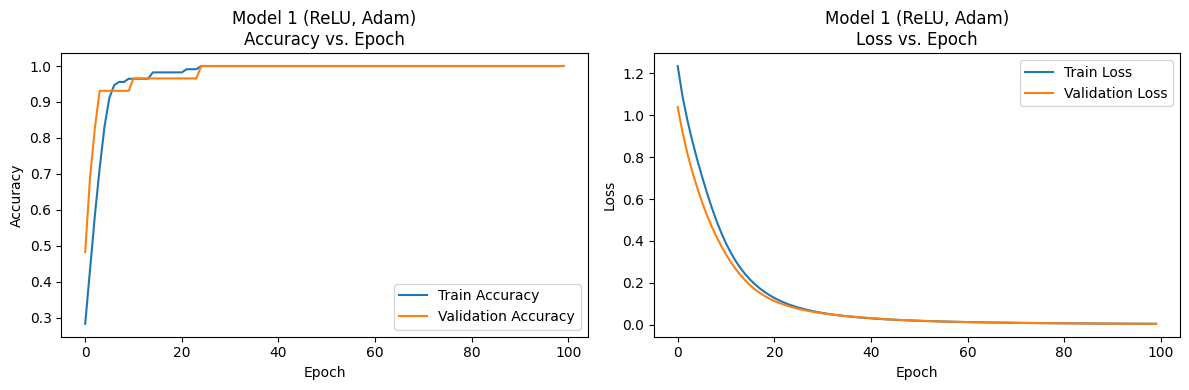

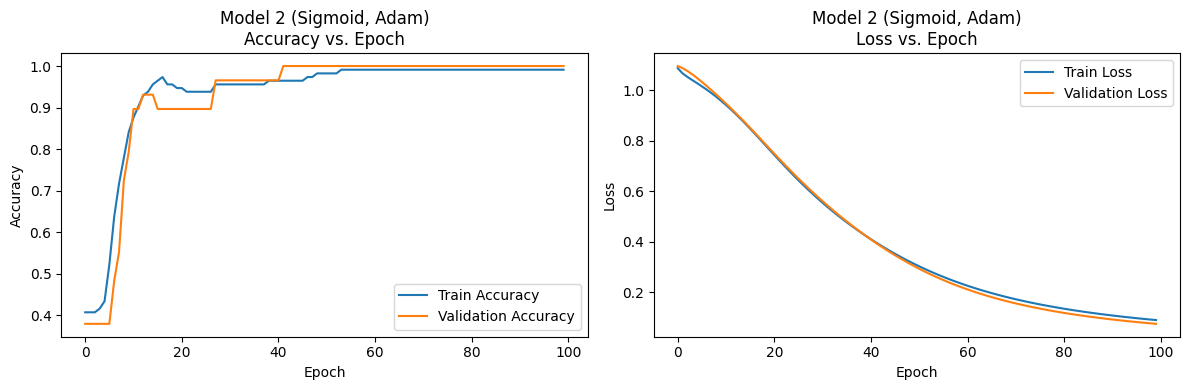

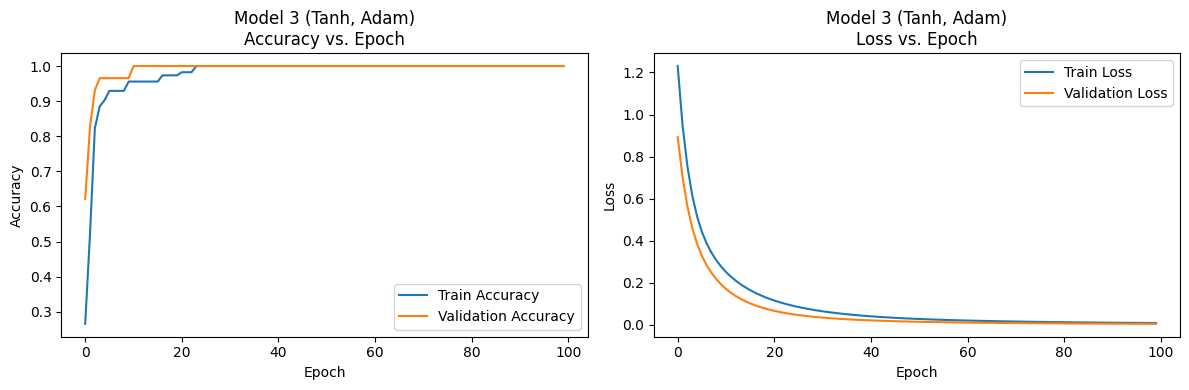

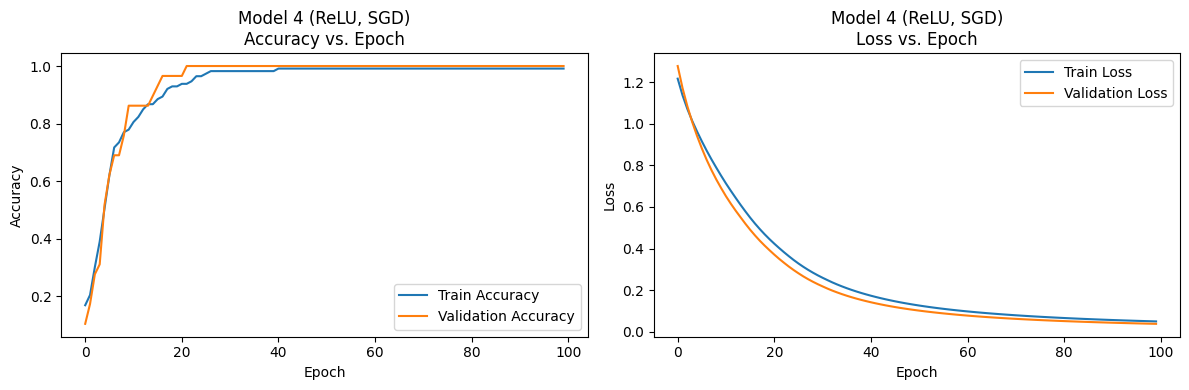

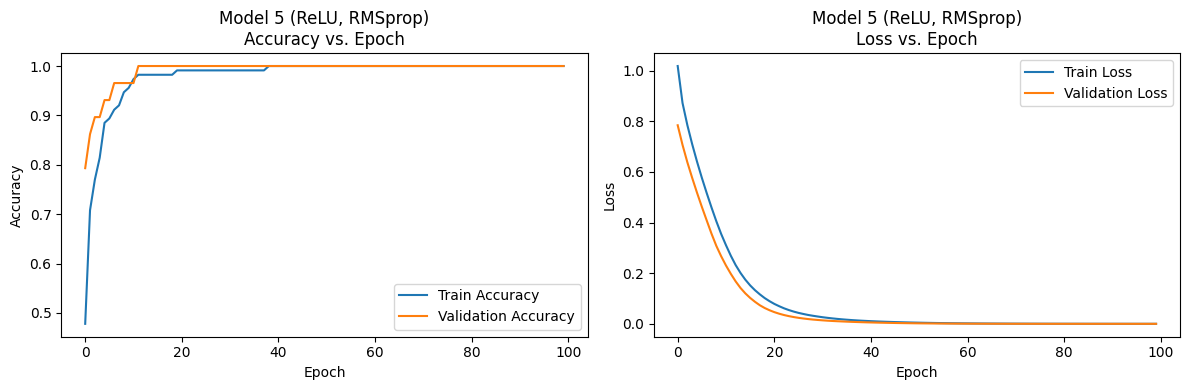

In [14]:
def plot_history(name, history):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["accuracy"], label="Train Accuracy")
    axes[0].plot(hist["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{name}\nAccuracy vs. Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(hist["loss"], label="Train Loss")
    axes[1].plot(hist["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{name}\nLoss vs. Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

for name, history in histories.items():
    plot_history(name, history)


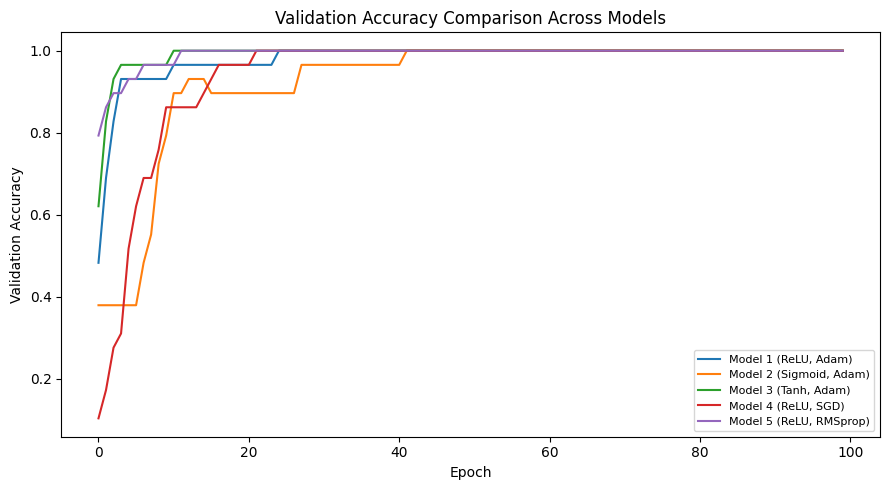

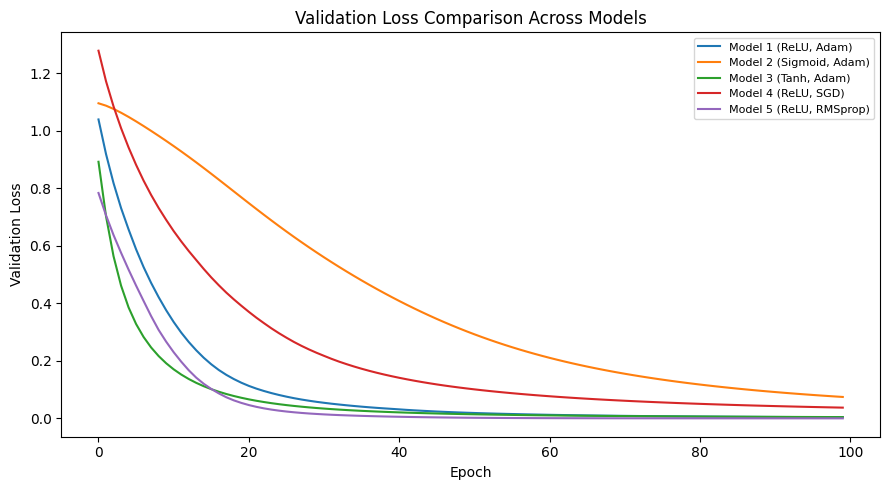

In [15]:
# Overlay comparison: validation accuracy across all 5 models (activation & optimizer effects)
plt.figure(figsize=(9, 5))
for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], label=name)
plt.title("Validation Accuracy Comparison Across Models")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
for name, history in histories.items():
    plt.plot(history.history["val_loss"], label=name)
plt.title("Validation Loss Comparison Across Models")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. Model Evaluation - Confusion Matrices


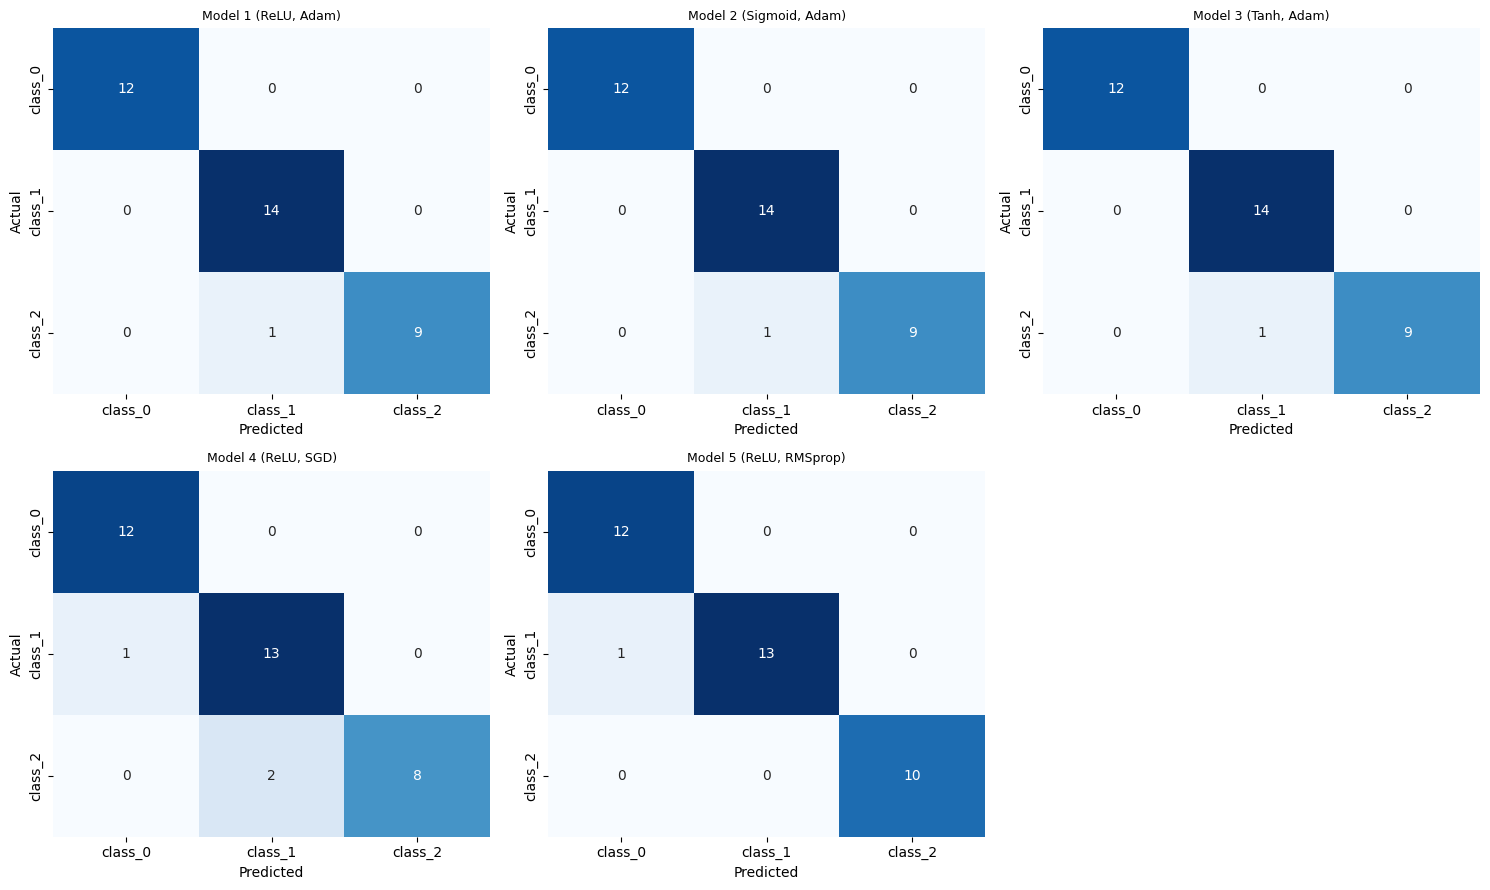

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_dict.items()):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=data.target_names, yticklabels=data.target_names,
                ax=axes[idx])
    axes[idx].set_title(name, fontsize=9)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

# Hide any unused subplot
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [17]:
# Detailed classification report for the best-performing model (by test accuracy)
best_name = max(results, key=lambda k: results[k]["test_accuracy"])
best_model = models_dict[best_name]
y_pred_best = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true_best = np.argmax(y_test, axis=1)

print(f"Best model by test accuracy: {best_name}\n")
print(classification_report(y_true_best, y_pred_best, target_names=data.target_names))


Best model by test accuracy: Model 1 (ReLU, Adam)

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## 7. Comparison Table


In [18]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["activation", "optimizer", "test_accuracy",
                                "precision", "recall", "f1_score",
                                "train_acc", "val_acc", "train_loss", "val_loss"]]
comparison_df = comparison_df.round(4)
comparison_df


,activation,optimizer,test_accuracy,precision,recall,f1_score,train_acc,val_acc,train_loss,val_loss
"Model 1 (ReLU, Adam)",relu,adam,0.972222,0.977778,0.966667,0.970962,1.0,1.0,0.004042,0.003878
"Model 2 (Sigmoid, Adam)",sigmoid,adam,0.972222,0.977778,0.966667,0.970962,0.99115,1.0,0.089298,0.074396
"Model 3 (Tanh, Adam)",tanh,adam,0.972222,0.977778,0.966667,0.970962,1.0,1.0,0.00819,0.004376
"Model 4 (ReLU, SGD)",relu,sgd,0.916667,0.929915,0.909524,0.915147,0.99115,1.0,0.048923,0.03727
"Model 5 (ReLU, RMSprop)",relu,rmsprop,0.972222,0.974359,0.97619,0.974321,1.0,1.0,0.000095,0.000022


In [19]:
# Save the comparison table
comparison_df.to_csv("model_comparison_results.csv")
print("Saved to model_comparison_results.csv")


Saved to model_comparison_results.csv
